In [1]:
import numpy as np
import matplotlib.pyplot as plt


#### Partie 1 : Récupération ou génération de données 

Les données du cas 1 représentent les tailles des élèves d'une classe de CE1.

In [11]:
#Cas 1 : Récupération de données 
X=np.array([123.9, 126.,109.1,137.1,125.3,115.,123.8,128.7,120.7,119.8,
            110.4,122.9,121.1,121.8,123.8,120.1,130.1,119.4,121.1,132.6,
            117.7,125.3,119.1,130.3,121.1,110.1,129.6,115.7,128.9,122.5])

#Cas 2 : Génération de données synthétique (pour vérifier plus tard les propriétés théoriques d'estimateurs des paramètres)
"""
mu = 122 # Moyenne de la distribution
sigma = 7 # Écart type de la distribution
N = 30 # Nombre d'observations souhaité
X = np.random.normal(loc=mu, scale=sigma, size=N) #une loi normale est choisie ici
"""


"\nmu = 122 # Moyenne de la distribution\nsigma = 7 # Écart type de la distribution\nN = 30 # Nombre d'observations souhaité\nX = np.random.normal(loc=mu, scale=sigma, size=N) #une loi normale est choisie ici\n"

In [3]:
# Affichage des N observations
print("Observations : ", np.round(X,1))

Observations :  [123.9 126.  109.1 137.1 125.3 115.  123.8 128.7 120.7 119.8 110.4 122.9
 121.1 121.8 123.8 120.1 130.1 119.4 121.1 132.6 117.7 125.3 119.1 130.3
 121.1 110.1 129.6 115.7 128.9 122.5]


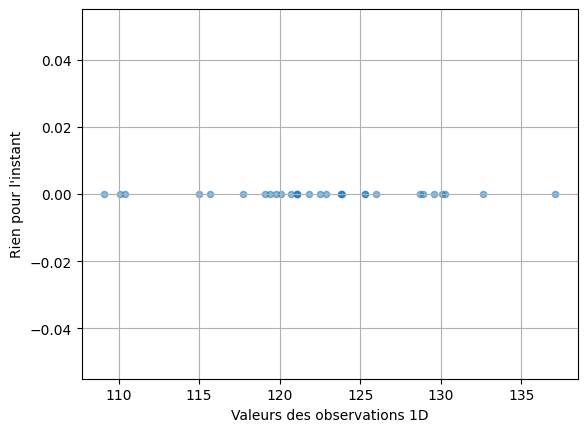

In [4]:
# Affichage des N observations
plt.scatter(X, 0.*np.arange(len(X)), s=20, alpha=0.5)

# Configuration du graphique
plt.xlabel('Valeurs des observations 1D')
plt.ylabel('Rien pour l\'instant')
plt.grid()
plt.show()

#### Partie 2 : Estimation des propriétés de la distribution des données 



##### 2.1 : Estimation visuelle

Nous allons faire l'hypothèse que ces données suivent une loi Normale de moyenne $\mu$ et d'écart type $\sigma$. Essayons de confronter visuellement les distributions avec plusieurs paramètres aux observations. 

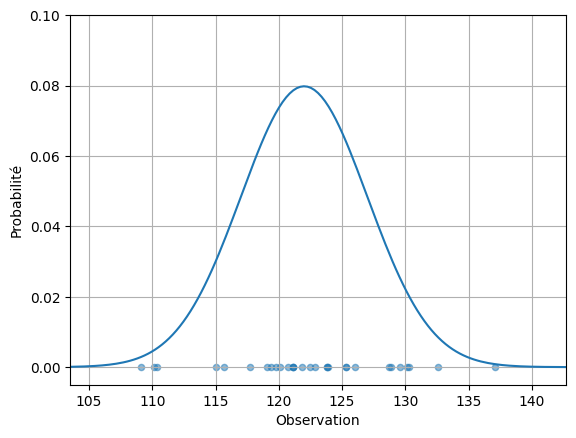

In [5]:
from scipy.stats import norm

def Show_1D_observations_and_normal_prob_dens(X,mu=0,sigma=1):
    """
    X: 1D numpy array containing the observaed data
    mu: normal distribution mean
    sigma: normal distribution standard deviation
    """

    # Compute the theoretical probability density
    x_min, x_max = np.min(X), max(X) # domain boundaries
    dx = (x_max-x_min)/100
    x_min=x_min-20*dx
    x_max=x_max+20*dx
    x_theo = np.arange(x_min, x_max + dx, dx)
    p_x_theo = norm.pdf(x_theo, loc=mu, scale=sigma) # Calcul de la densité de probabilité théorique pour chaque valeur de `x`

    # Affichage des résultats
    plt.scatter(X, 0.*np.arange(len(X)), s=20, alpha=0.5)
    plt.plot(x_theo, p_x_theo)
    plt.axis([x_min,x_max,-0.005,0.1])
    plt.xlabel('Observation')
    plt.ylabel('Probabilité')
    plt.grid() 
    plt.show() 

Show_1D_observations_and_normal_prob_dens(X,mu=122,sigma=5)


##### 2.2 : Estimation au sens du maximum de vraisemblance

Il semble évident qu'un critère objectif soit nécessaire pour trouver un résultat optimal. Nous allons alors utiliser la notion de vraisemblance pour mesurer l'adéquation entre observations et paramètres qui les expliquent. Les meilleurs paramètres seront ceux qui maximisent la vraisemblance.  

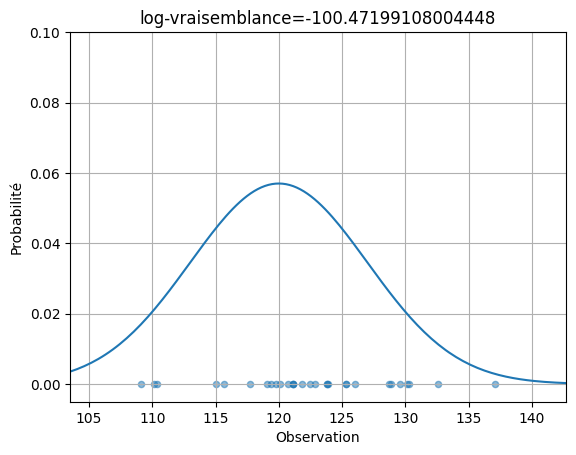

In [16]:
from scipy.stats import norm

def Show_1D_observations_and_normal_prob_dens_with_loglikelihood(X,mu=0,sigma=1):
    """
    X: 1D numpy array containing the observaed data
    mu: normal distribution mean
    sigma: normal distribution standard deviation
    """

    # Compute the theoretical probability density
    x_min, x_max = np.min(X), max(X) # domain boundaries
    dx = (x_max-x_min)/100
    x_min=x_min-20*dx
    x_max=x_max+20*dx
    x_theo = np.arange(x_min, x_max + dx, dx)
    p_x_theo = norm.pdf(x_theo, loc=mu, scale=sigma) # Calcul de la densité de probabilité théorique pour chaque valeur de `x`

    #compute the log-likelihood
    p_x_obs = norm.pdf(X, loc=mu, scale=sigma)
    likelihood=p_x_obs.prod()
    loglikelihood=np.log(likelihood)

    # Affichage des résultats
    plt.scatter(X, 0.*np.arange(len(X)), s=20, alpha=0.5)
    plt.plot(x_theo, p_x_theo)
    plt.axis([x_min,x_max,-0.005,0.1])
    plt.xlabel('Observation')
    plt.ylabel('Probabilité')
    plt.title('log-vraisemblance='+str(loglikelihood))
    plt.grid() 
    plt.show() 

Show_1D_observations_and_normal_prob_dens_with_loglikelihood(X,mu=120,sigma=7)

Remarque : On aurait pu trouver des résultats optimaux avec la moyenne et l'écart-type des observations...

In [7]:
print(X.mean())
print(X.std())


122.43333333333334
6.444549807567804


#### Partie 3 : Estimation du maximum de vraisemblance d'une loi plus complexe 

Nous allons maintenant nous intéresser au temps d'attente à la caisse d'un magasin à un certain moment dans la semaine. La loi de distribution qui modélise ce phénomène est une loi exponentielle. Elle dépend d'un paramètre d'échelle $\beta$ et n'est pas symétrique comme la loi normale. Sa densité de probabilité est $f(x; \frac{1}{\beta}) = \frac{1}{\beta} \exp \left( -\frac{x}{\beta} \right)$.

##### 3.1 : Génération de données synthétiques

   Statistiques des temps d'attente (heures)
   Moyenne  : 0.14
   Médiane  : 0.03
   Écart-type: 0.23
   Minimum  : 0.00
   Maximum  : 1.33
   90e percentile : 0.39
   % clients sans attente : 42.6%


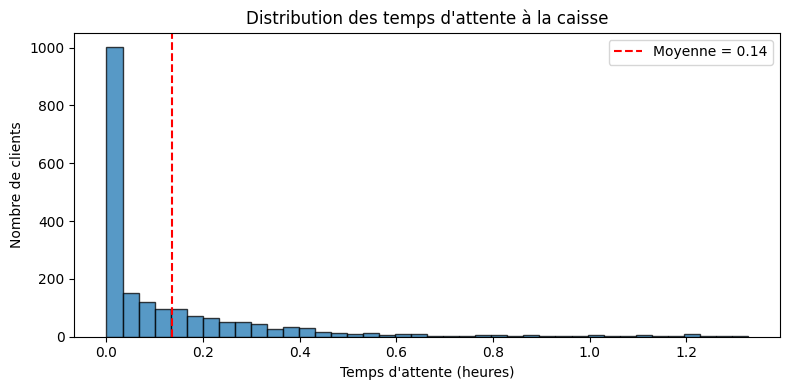

In [8]:
import random
import numpy as np
from typing import List

def simuler_temps_attente(nb_clients: int,taux_arrivee: float,taux_service: float,seed: int = None) -> List[float]:
    """
    Simule les temps d'attente à une caisse unique (modèle M/M/1).

    Paramètres:
        nb_clients   : Nombre de clients à simuler
        taux_arrivee : Nombre moyen d'arrivées par unité de temps (λ)
        taux_service : Nombre moyen de clients servis par unité de temps (μ)
        seed         : Graine pour reproductibilité (optionnel)

    Retourne:
        Liste des temps d'attente (en unités de temps) pour chaque client
    """
    if taux_arrivee >= taux_service:
        raise ValueError("Le taux d'arrivée doit être strictement inférieur au taux de service pour une file stable.")
    if nb_clients <= 0:
        raise ValueError("Le nombre de clients doit être supérieur à 0.")

    if seed is not None:
        random.seed(seed)

    serveur_libre_a = 0.0
    temps_arrivee = 0.0
    temps_attente = []

    # Pré-générer les intervalles entre arrivées et durées de service
    intervalles = [random.expovariate(taux_arrivee) for _ in range(nb_clients)]
    services = [random.expovariate(taux_service) for _ in range(nb_clients)]

    for i in range(nb_clients):
        temps_arrivee += intervalles[i]
        duree_service = services[i]

        # Le service commence à l'arrivée si le serveur est libre, sinon à la libération du serveur
        debut_service = max(temps_arrivee, serveur_libre_a)
        attente = debut_service - temps_arrivee

        temps_attente.append(attente)
        serveur_libre_a = debut_service + duree_service

    return temps_attente


def afficher_statistiques(temps: List[float], unite: str = "unités de temps"):
    """Affiche les statistiques descriptives des temps d'attente."""
    print(f"   Statistiques des temps d'attente ({unite})")
    print(f"   Moyenne  : {np.mean(temps):.2f}")
    print(f"   Médiane  : {np.median(temps):.2f}")
    print(f"   Écart-type: {np.std(temps):.2f}")
    print(f"   Minimum  : {np.min(temps):.2f}")
    print(f"   Maximum  : {np.max(temps):.2f}")
    print(f"   90e percentile : {np.percentile(temps, 90):.2f}")
    print(f"   % clients sans attente : {sum(1 for t in temps if t == 0) / len(temps) * 100:.1f}%")


# Paramètres réalistes (ex: supermarché)
nb_clients= 2000
taux_arrivee= 7.0   # taux de clients arrivant chaque heure
taux_service= 12.0   # taux de clients servis à la caisse chaque heure
UNITE= "heures"


X = simuler_temps_attente(nb_clients, taux_arrivee, taux_service, seed=42)
afficher_statistiques(X, UNITE)

plt.figure(figsize=(8, 4))
plt.hist(X, bins=40, edgecolor='black', alpha=0.75)
plt.title("Distribution des temps d'attente à la caisse")
plt.xlabel(f"Temps d'attente ({UNITE})")
plt.ylabel("Nombre de clients")
plt.axvline(np.mean(X), color='red', linestyle='--', label=f"Moyenne = {np.mean(X):.2f}")
plt.legend()
plt.tight_layout()
plt.show()


##### 3.2 : Estimation de l'échelle $\beta$ de la loi exponentielle

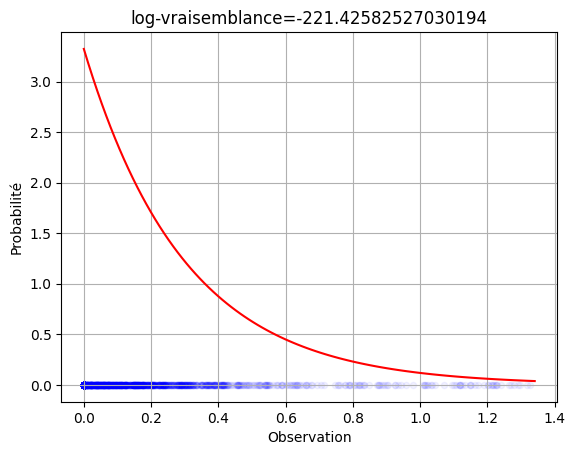

In [9]:
from scipy.stats import expon

def Show_1D_observations_and_expon_prob_dens_with_loglikelihood(X,beta=1):
    """
    X: 1D numpy array containing the observaed data
    mu: normal distribution mean
    sigma: normal distribution standard deviation
    """

    # Compute the theoretical probability density
    x_min, x_max = np.min(X), max(X) # domain boundaries
    dx = (x_max-x_min)/100
    x_theo = np.arange(x_min, x_max + dx, dx)
    p_x_theo = expon.pdf(x_theo, loc=-0.001, scale=beta) # Calcul de la densité de probabilité théorique pour chaque valeur de `x`

    #compute the log-likelihood
    p_x_obs = norm.pdf(X, loc=-0.001, scale=beta)
    likelihood=p_x_obs.prod()
    loglikelihood=np.log(likelihood)

    # Affichage des résultats
    plt.scatter(X, 0.*np.arange(len(X)), s=20, alpha=0.05,c='b')
    plt.plot(x_theo, p_x_theo,c='r')
    #plt.axis([x_min-20*dx,x_max+20*dx,-0.005,0.1])
    plt.xlabel('Observation')
    plt.ylabel('Probabilité')
    plt.title('log-vraisemblance='+str(loglikelihood))
    plt.grid() 
    plt.show() 

Show_1D_observations_and_expon_prob_dens_with_loglikelihood(X,beta=0.3)